<a href="https://colab.research.google.com/github/Azyur-i/CS182-03/blob/main/FA6/C01FA6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Loading Libraries and Setting Up Utilities
# We import the core libraries needed for Time Series Analysis:
# Pandas and NumPy for data manipulation and date-time handling
# Matplotlib and Seaborn for visualizing trends and forecasts
# Statsmodels for the Augmented Dickey-Fuller test for stationarity and ARIMA modeling
# Sklearn metrics to evaluate the forecast using MSE and MAE

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

sns.set(style="whitegrid")

In [2]:
# 2. Creating and Loading the Dataset
# we generate a synthetic monthly House Price dataset
# to ensure this script is self-contained.

np.random.seed(42)

dates = pd.date_range(start='2015-01-01', periods=120, freq='ME')

trend = np.linspace(200000, 400000, 120)
seasonality = 10000 * np.sin(np.linspace(0, 3.14 * 20, 120))
noise = np.random.normal(0, 5000, 120)

prices = trend + seasonality + noise
df = pd.DataFrame({'Date': dates, 'Price': prices})
df.set_index('Date', inplace=True)

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (120, 1)
                    Price
Date                     
2015-01-31  202483.570765
2015-02-28  206025.094885
2015-03-31  215301.068200
2015-04-30  222656.397677
2015-05-31  214128.350630


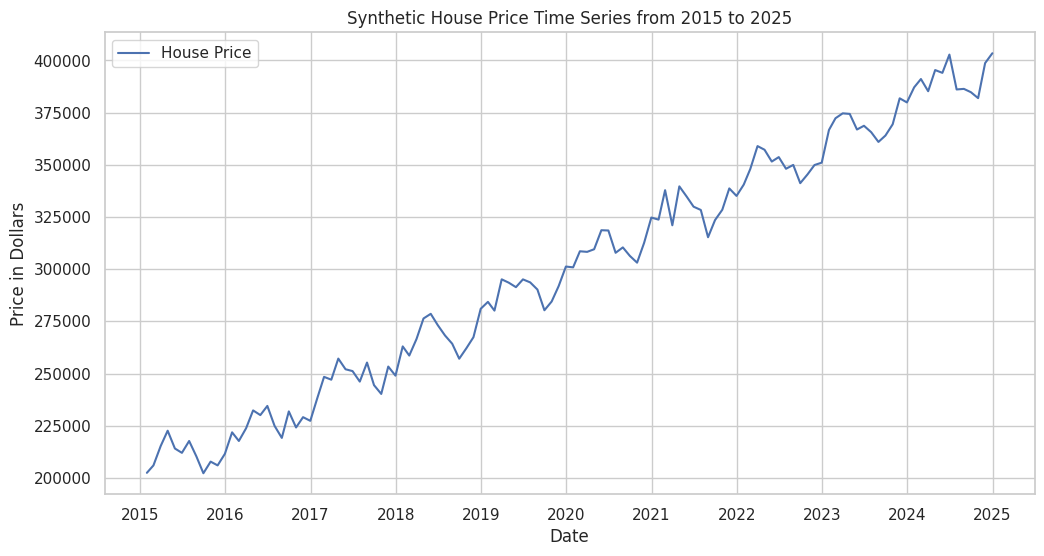

In [3]:
# 3. Visualizing the raw data

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Price'], label='House Price')
plt.title("Synthetic House Price Time Series from 2015 to 2025")
plt.xlabel("Date")
plt.ylabel("Price in Dollars")
plt.legend()
plt.show()

Training Samples: 84
Testing Samples: 36


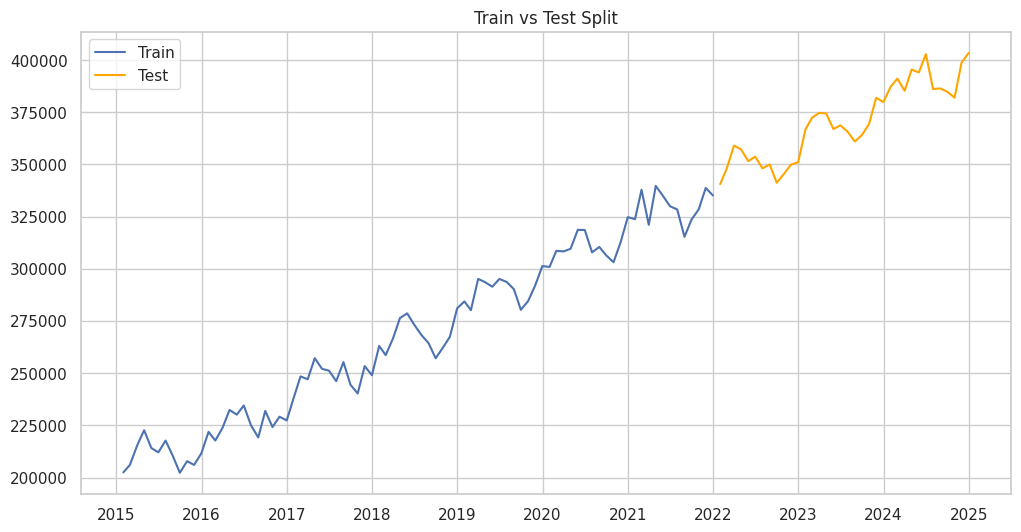

In [4]:
# 4. Splitting and Visualizing the Dataset
# For Time Series, we CANNOT use random splitting such as train_test_split.
# We must split chronologically to respect the order of time.

# Training: First 70% of months
# Testing: Last 30% of months

train_size = int(len(df) * 0.7)
train_data, test_data = df.iloc[:train_size], df.iloc[train_size:]

print(f"Training Samples: {len(train_data)}")
print(f"Testing Samples: {len(test_data)}")

plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Price'], label='Train')
plt.plot(test_data.index, test_data['Price'], label='Test', color='orange')
plt.title("Train vs Test Split")
plt.legend()
plt.show()

In [5]:
# 5. Training the ARIMA Model
# We implement an ARIMA model which stands for AutoRegressive Integrated Moving Average.
# Based on the synthetic trend, we select order 5, 1, 0 as a baseline.
# In a full study, we would use ACF and PACF plots to determine these numbers.

model = ARIMA(train_data['Price'], order=(5, 1, 0))
model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [6]:
# 6. Forecasting and Evaluation
# We forecast for the duration of the test set and compare with actuals.
# Evaluation metrics used:
# - RMSE or Root Mean Squared Error which penalizes large errors.
# - MAE or Mean Absolute Error which is the average magnitude of errors.

forecast_result = model_fit.get_forecast(steps=len(test_data))
forecast = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

forecast.index = test_data.index
conf_int.index = test_data.index

rmse = np.sqrt(mean_squared_error(test_data['Price'], forecast))
mae = mean_absolute_error(test_data['Price'], forecast)

print(f"Model Performance:\nRMSE: {rmse:.2f}\nMAE: {mae:.2f}")

Model Performance:
RMSE: 40137.87
MAE: 35770.41


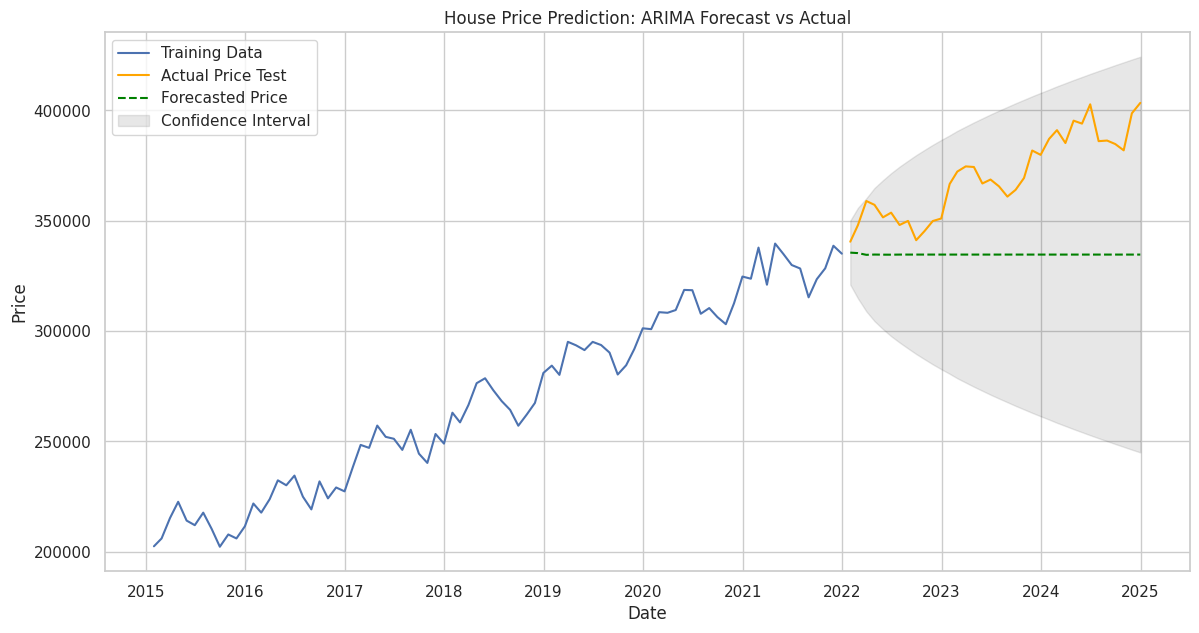

In [7]:
# 7. Plotting the Final Result
# Plotting Confidence Intervals to show Uncertainty

plt.figure(figsize=(14, 7))
plt.plot(train_data.index, train_data['Price'], label='Training Data')
plt.plot(test_data.index, test_data['Price'], label='Actual Price Test', color='orange')
plt.plot(forecast.index, forecast, label='Forecasted Price', color='green', linestyle='--')

plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='k', alpha=0.1, label='Confidence Interval')

plt.title("House Price Prediction: ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

**REFERENCES:**

Bonniema. n.d. House-Price-Prediction-with-Time-Series. GitHub. https://github.com/bonniema/House-Price-Prediction-with-Time-Series

Statsmodels. 2024. Statsmodels Computer software. https://www.statsmodels.org/stable/index.html

NumPy. https://numpy.org/doc/

Pandas - NumFOCUS, Inc. 2026. https://pandas.pydata.org/about/

The Matplotlib development team - Matplotlib 2012. https://matplotlib.org/

Scikit-learn. https://scikit-learn.org/stable/about.html